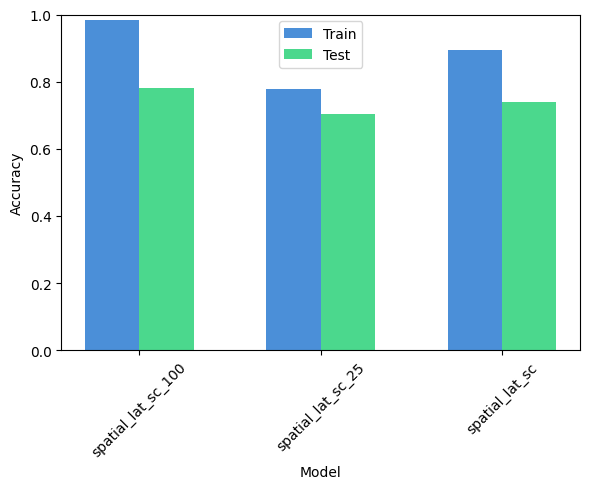

In [6]:
import json
import matplotlib.pyplot as plt
from pathlib import Path
from glob import glob
import numpy as np

from colors import colors

files = sorted(glob('../output_results/E_sent/main-2/*.json'))
if not files:
    raise FileNotFoundError('No matching files found')
files.append('../output_results/E_sent/main/lat_sc_2026-04-28_13-42-47_e-50_s-25_spatial.json')

file_labels = []
train_accuracies = []
test_accuracies = []
for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as file:
        data = json.load(file)

    file_name = Path(file_path).name
    file_labels.append('_'.join([data.get('training_config', {}).get('input_mode'), data.get('training_config', {}).get('output_file_prefix') or 'poisson_sc']))
    train_accuracies.append(data['results']['epoch_train_accuracy'][-1])
    test_accuracies.append(data['results']['test_accuracy'])

x = np.arange(len(files))
width = 0.3

fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(x - width / 2, train_accuracies, width, label='Train', color=colors.train_accuracy)
ax.bar(x + width / 2, test_accuracies, width, label='Test', color=colors.test_accuracy)
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(file_labels, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()